# Import Data

In [ ]:
import pandas as pd
github_raw_url = 'https://raw.githubusercontent.com/Danielbarz/analisis-sentimen-padel/main/Padel_Preprocessed.xlsx'
df = pd.read_excel(github_raw_url)
print("Dataset berhasil dimuat!")

Dataset berhasil dimuat!


In [ ]:
df.head()

,judul,url,sumber,tanggal,keyword,metode_scraping,konten,konten_norm,konten_stemmed,label,label_text
0,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...",https://news.google.com/rss/articles/CBMixgFBV...,CNN Indonesia,2026-01-26 08:00:00,padel trend Indonesia,google_news_180d,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...",riset laju properti 2026 moderat lapangan pade...,riset laju properti 2026 moderat lapang padel ...,1,netral
1,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,https://news.google.com/rss/articles/CBMiowFBV...,Bloomberg Technoz,2026-02-28 08:00:00,padel,google_news_180d,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,berapa biaya bangun lapangan padel ini rincian...,biaya bangun lapang padel rinciannya bloomberg...,1,netral
2,"Maple Padel, Lapangan Padel Rooftop Pertama di...",https://news.google.com/rss/articles/CBMiYkFVX...,RRI.co.id,2026-02-06 08:00:00,komunitas padel,google_news_180d,"Maple Padel, Lapangan Padel Rooftop Pertama di...",maple padel lapangan padel rooftop pertama di ...,maple padel lapang padel rooftop jateng,1,netral
3,Pramono Resmi Larang Pembangunan Lapangan Pade...,https://news.google.com/rss/articles/CBMizwFBV...,CNN Indonesia,2026-02-24 08:00:00,lapangan padel Jakarta,google_news_180d,Pramono Resmi Larang Pembangunan Lapangan Pade...,pramono resmi larang pembangunan lapangan pade...,pramono resmi larang bangun lapang padel zona ...,1,netral
4,Baru Pertama Main Padel? Ini Cara Bermain yang...,https://sport.detik.com/sportstyle/d-8174724/b...,Detik.com,NaT,padel pemula,detik_search,Padel kini menjadi olahraga viral yang banyak ...,padel kini menjadi olahraga viral yang banyak ...,padel olahraga viral gari indonesia cinta olah...,2,positif


# DATA PREPROCESSING
- Uppercase to Lowercase — normalisasi teks
- Stopwords Removal — penghapusan kata-kata tidak bermakna (NLTK + custom)
- Lemmatization — pemotongan ke kata dasar menggunakan PySastrawi


Berikut adalah penjelasan singkat untuk setiap langkah *data preprocessing* yang telah dilakukan:

### 1. Uppercase to Lowercase
Langkah ini bertujuan untuk menormalisasi teks dengan mengubah semua huruf kapital menjadi huruf kecil. Tujuannya adalah agar kata yang sama namun memiliki perbedaan kapitalisasi (misalnya, "Padel" dan "padel") dianggap sebagai satu entitas yang sama dalam analisis. Ini membantu mengurangi duplikasi dan menyederhanakan data untuk pemrosesan lebih lanjut.

### 2. Stopwords Removal
Penghapusan *stopwords* adalah proses menghilangkan kata-kata umum yang tidak memberikan makna signifikan atau informasi berharga dalam analisis teks (misalnya, "yang", "dan", "di", "untuk"). Tahap ini menggunakan daftar *stopwords* dari NLTK untuk bahasa Indonesia dan juga menambahkan *stopwords* kustom yang relevan dengan dataset ini. Tujuannya adalah untuk fokus pada kata-kata kunci yang lebih informatif.

### 3. Lemmatization
*Lemmatization* adalah proses mengubah kata-kata menjadi bentuk dasarnya atau akar kata (lemma). Misalnya, kata "bermain", "memainkan", atau "dimainkan" akan dikembalikan menjadi "main". Proses ini menggunakan pustaka PySastrawi untuk bahasa Indonesia. Tujuan utamanya adalah untuk mengurangi infleksi kata dan mengelompokkan kata-kata yang memiliki makna dasar yang sama, sehingga meningkatkan akurasi analisis teks.

Uppercase to Lowercase

In [ ]:
def to_lowercase(text: str) -> str:
    if not isinstance(text, str):
        return ''
    return text.lower()

df['to_lowercase'] = df['konten'].apply(to_lowercase)

print('=== Sample: Original konten ===')
print(df['konten'].iloc[0][:300])
print('\n=== Sample: After Lowercase ===')
print(df['to_lowercase'].iloc[0][:300])

=== Sample: Original konten ===
Riset: Laju Properti 2026 Moderat, Lapangan Padel Justru Meningkat&nbsp;&nbsp;CNN Indonesia

=== Sample: After Lowercase ===
riset: laju properti 2026 moderat, lapangan padel justru meningkat&nbsp;&nbsp;cnn indonesia


Stopwords Removal

In [ ]:
import re
import html

def clean_text(text):
    # decode HTML entities (&nbsp; jadi spasi)
    text = html.unescape(text)

    # hapus sisa 'nbsp' kalau masih muncul
    text = re.sub(r'\bnbsp\b', ' ', text)

    return text

In [ ]:
df['clean_text'] = df['to_lowercase'].apply(clean_text)

In [ ]:
import re
import nltk
from nltk.tokenize import word_tokenize

# Unduh tokenizer jika belum ada
try:
    word_tokenize('test')
except LookupError:
    # Error message indicates 'punkt_tab' is missing, so download that.
    nltk.download('punkt_tab')

def tokenize_text(text: str) -> list:
    if not isinstance(text, str):
        return []
    # Tokenize the cleaned text
    tokens = word_tokenize(text)
    # Remove single characters that are not digits (often noise)
    # This also helps ensure 'nbsp' (if it somehow slipped through) as a single token is removed.
    tokens = [t for t in tokens if len(t) > 1 or t.isdigit()]
    return tokens

df['before_stopwords'] = df['clean_text'].apply(tokenize_text)

print('Sample tokens (before stopwords):')
print(df['before_stopwords'].iloc[0][:30])

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Sample tokens (before stopwords):
['riset', 'laju', 'properti', '2026', 'moderat', 'lapangan', 'padel', 'justru', 'meningkat', 'cnn', 'indonesia']


In [ ]:
import nltk
from nltk.corpus import stopwords
from collections import Counter

# Unduh stopwords jika belum ada
try:
    stopwords.words('indonesian')
except LookupError:
    nltk.download('stopwords')

# Round 1: Apply only NLTK stopwords, then inspect top 100
nltk_stopwords = set(stopwords.words('indonesian'))

def remove_stopwords(tokens: list, sw_set: set) -> list:
    return [t for t in tokens if t not in sw_set]

tokens_after_nltk = df['before_stopwords'].apply(lambda t: remove_stopwords(t, nltk_stopwords))

all_tokens_r1 = [token for tokens in tokens_after_nltk for token in tokens]
# Remove words containing 'nbsp'
all_tokens_r1 = [token for token in all_tokens_r1 if 'nbsp' not in token]

freq_r1 = Counter(all_tokens_r1)
top100_r1 = pd.DataFrame(freq_r1.most_common(100), columns=['kata', 'frekuensi'])

print('=== TOP 100 KATA (setelah NLTK stopwords dan penghapusan ===')
print('Perhatikan kata-kata yang masih tidak bermakna untuk ditambahkan ke custom stopwords.\n')
print(top100_r1.to_string())

=== TOP 100 KATA (setelah NLTK stopwords dan penghapusan ===
Perhatikan kata-kata yang masih tidak bermakna untuk ditambahkan ke custom stopwords.

             kata  frekuensi
0           padel       1943
1        lapangan        815
2        olahraga        537
3              ``        356
4              ''        355
5         jakarta        319
6           raket        280
7       indonesia        224
8        turnamen        223
9         bermain        164
10          atlet        131
11      komunitas        124
12         pemain        118
13       memiliki        116
14          warga        110
15           kota        106
16      permainan         99
17      fasilitas         99
18       bangunan         98
19          harga         97
20         lokasi         97
21          tenis         92
22            jam         88
23           sewa         86
24         pemula         85
25            dki         81
26             to         80
27           main         80
28         

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
additional_stopwords = [
    # Noise web / scraping
    'com', 'id', 'co', 'scroll', 'continue', 'with', 'content', 'to', 'the',

    # Satuan / angka / umum banget
    'rp', 'ribu', 'jam', 'nomor', 'area',

    # Kata terlalu umum (tidak spesifik insight)
    'memiliki', 'salah', 'orang', 'ya', 'cocok', 'nyaman', 'membantu',
    'pilihan', 'terbaik', 'mudah', 'aktif', 'sesuai',

    # Kata generik aktivitas
    'kegiatan', 'aktivitas', 'gaya', 'hidup',

    # Kata lokasi terlalu umum (opsional, tergantung analisis)
    'kota', 'daerah', 'kawasan', 'jalan', 'selatan', 'timur',

    # Kata media / platform
    'detikers', 'detikcom', 'tvonenews', 'artikel', 'video', 'instagram',

    # Kata kurang informatif dalam konteks
    'suara', 'izin', 'malam', 'kali' , '``' , "''", "com", "id"
]

print(f'Additional stopwords ditambahkan: {len(additional_stopwords)} kata')
print(additional_stopwords)

Additional stopwords ditambahkan: 50 kata
['com', 'id', 'co', 'scroll', 'continue', 'with', 'content', 'to', 'the', 'rp', 'ribu', 'jam', 'nomor', 'area', 'memiliki', 'salah', 'orang', 'ya', 'cocok', 'nyaman', 'membantu', 'pilihan', 'terbaik', 'mudah', 'aktif', 'sesuai', 'kegiatan', 'aktivitas', 'gaya', 'hidup', 'kota', 'daerah', 'kawasan', 'jalan', 'selatan', 'timur', 'detikers', 'detikcom', 'tvonenews', 'artikel', 'video', 'instagram', 'suara', 'izin', 'malam', 'kali', '``', "''", 'com', 'id']


In [ ]:
# Combine NLTK + custom stopwords
final_stopwords = nltk_stopwords.union(set(additional_stopwords))
print(f'Total stopwords (NLTK + custom): {len(final_stopwords)}')

# Apply final stopwords -> after_stopwords
df['after_stopwords'] = df['before_stopwords'].apply(
    lambda tokens: remove_stopwords(tokens, final_stopwords)
)

print('\n=== Sample: before_stopwords ===')
print(df['before_stopwords'].iloc[0][:20])
print('\n=== Sample: after_stopwords ===')
print(df['after_stopwords'].iloc[0][:20])

Total stopwords (NLTK + custom): 805

=== Sample: before_stopwords ===
['riset', 'laju', 'properti', '2026', 'moderat', 'lapangan', 'padel', 'justru', 'meningkat', 'cnn', 'indonesia']

=== Sample: after_stopwords ===
['riset', 'laju', 'properti', '2026', 'moderat', 'lapangan', 'padel', 'meningkat', 'cnn', 'indonesia']


In [ ]:
# Top 100 words after full stopwords removal
all_tokens_final = [token for tokens in df['after_stopwords'] for token in tokens]
freq_final = Counter(all_tokens_final)
top100_after_sw = pd.DataFrame(freq_final.most_common(100), columns=['kata', 'frekuensi'])

print('=== TOP 100 KATA (setelah NLTK + custom stopwords) ===')
# top100_after_sw
print(top100_after_sw.to_string())

=== TOP 100 KATA (setelah NLTK + custom stopwords) ===
             kata  frekuensi
0           padel       1943
1        lapangan        815
2        olahraga        537
3         jakarta        319
4           raket        280
5       indonesia        224
6        turnamen        223
7         bermain        164
8           atlet        131
9       komunitas        124
10         pemain        118
11          warga        110
12      permainan         99
13      fasilitas         99
14       bangunan         98
15          harga         97
16         lokasi         97
17          tenis         92
18           sewa         86
19         pemula         85
20            dki         81
21           main         80
22           2025         79
23           2026         78
24     masyarakat         78
25           bola         78
26          ruang         78
27          pajak         78
28    rekomendasi         71
29        disegel         64
30       nasional         60
31       surabaya

Lemmatization (Mengubah ke kata dasr)

In [ ]:
import sys
!{sys.executable} -m pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 17.5 MB/s eta 0:00:00


In [ ]:
# Initialize Sastrawi stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def lemmatize_tokens(tokens: list) -> list:
    return [stemmer.stem(t) for t in tokens]

print('Running lemmatization (Sastrawi)... This may take a moment.')
df['after_lemmatization'] = df['after_stopwords'].apply(lemmatize_tokens)

print('Done!')
print('\n=== Sample: after_stopwords ===')
print(df['after_stopwords'].iloc[0][:15])
print('\n=== Sample: after_lemmatization ===')
print(df['after_lemmatization'].iloc[0][:15])

Running lemmatization (Sastrawi)... This may take a moment.
Done!

=== Sample: after_stopwords ===
['riset', 'laju', 'properti', '2026', 'moderat', 'lapangan', 'padel', 'meningkat', 'cnn', 'indonesia']

=== Sample: after_lemmatization ===
['riset', 'laju', 'properti', '2026', 'moderat', 'lapang', 'padel', 'tingkat', 'cnn', 'indonesia']


In [ ]:
df['n_before_stopwords'] = df['before_stopwords'].apply(len)
df['n_after_stopwords']  = df['after_stopwords'].apply(len)
df['n_after_lemmatization'] = df['after_lemmatization'].apply(len)

avg_before = df['n_before_stopwords'].mean()
avg_after_stopwords  = df['n_after_stopwords'].mean()
avg_after_lemmatization = df['n_after_lemmatization'].mean()

# Reduction after stopwords removal
avg_reduction_stopwords = (1 - df['n_after_stopwords'] / df['n_before_stopwords']).mean() * 100

# Total reduction from original to after lemmatization
avg_total_reduction = (1 - df['n_after_lemmatization'] / df['n_before_stopwords']).mean() * 100

print('=== Word Count per Article ===')
print(df[['judul', 'n_before_stopwords', 'n_after_stopwords', 'n_after_lemmatization']].to_string())
print(f'\nAverage tokens before preprocessing : {avg_before:.1f}')
print(f'Average tokens after stopwords      : {avg_after_stopwords:.1f}')
print(f'Average reduction by stopwords      : {avg_reduction_stopwords:.1f}%')
print(f'Average tokens after lemmatization  : {avg_after_lemmatization:.1f}')
print(f'Total average reduction             : {avg_total_reduction:.1f}%')

=== Word Count per Article ===
                                                                                                                                                                                                                                                            judul  n_before_stopwords  n_after_stopwords  n_after_lemmatization
0                                                                                                                                                                              Riset: Laju Properti 2026 Moderat, Lapangan Padel Justru Meningkat - CNN Indonesia                  11                 10                     10
1                                                                                                                                                                                          Berapa Biaya Bangun Lapangan Padel? Ini Rinciannya - Bloomberg Technoz                   9                  7                      7
2        

In [ ]:
all_lemma_tokens = [token for tokens in df['after_lemmatization'] for token in tokens]
freq_lemma = Counter(all_lemma_tokens)
top100_lemma = pd.DataFrame(freq_lemma.most_common(100), columns=['kata_dasar', 'frekuensi'])

print('=== TOP 100 KATA DASAR (setelah lemmatization) ===')
top100_lemma

=== TOP 100 KATA DASAR (setelah lemmatization) ===


,kata_dasar,frekuensi
0,padel,1944
1,lapang,830
2,olahraga,574
3,main,500
4,jakarta,319
...,...,...
95,langsung,40
96,utama,40
97,2,40
98,penuh,39


## Simpan Data yang Sudah Diproses ke CSV

In [ ]:
import os

# Buat salinan DataFrame untuk operasi ekspor
df_export = df.copy()

# Kolom-kolom yang berisi list tokens perlu diubah menjadi string
df_export['before_stopwords'] = df_export['before_stopwords'].apply(lambda t: ' '.join(t))
df_export['after_stopwords'] = df_export['after_stopwords'].apply(lambda t: ' '.join(t))
df_export['after_lemmatization'] = df_export['after_lemmatization'].apply(lambda t: ' '.join(t))

# Tentukan kolom-kolom yang ingin disimpan dan urutannya
# Asumsi original_cols dan new_cols sudah didefinisikan sebelumnya
# Atau bisa juga tentukan secara manual jika diperlukan

# Example of defining original_cols and new_cols if they weren't globally available or updated:
original_cols = ['judul', 'url', 'sumber', 'tanggal', 'keyword', 'metode_scraping', 'konten', 'konten_norm', 'konten_stemmed', 'label', 'label_text']
new_cols = ['to_lowercase', 'clean_text', 'before_stopwords', 'n_before_stopwords', 'after_stopwords', 'n_after_stopwords', 'after_lemmatization', 'n_after_lemmatization', 'processed_text']

# Gabungkan dan filter kolom yang ada di df_export
final_cols = [col for col in (original_cols + new_cols) if col in df_export.columns]
df_export = df_export[final_cols]

# Tentukan path output
output_dir = 'output'
output_filename = 'articles_preprocessed_final.csv'
output_path = os.path.join(output_dir, output_filename)

# Pastikan direktori output ada
os.makedirs(output_dir, exist_ok=True)

# Simpan DataFrame ke CSV
df_export.to_csv(output_path, index=False)

print(f'DataFrame berhasil disimpan ke: {output_path}')
print(f'Jumlah baris: {len(df_export)}')
print(f'Kolom yang disimpan: {list(df_export.columns)}')
display(df_export.head(3))

DataFrame berhasil disimpan ke: output/articles_preprocessed_final.csv
Jumlah baris: 789
Kolom yang disimpan: ['judul', 'url', 'sumber', 'tanggal', 'keyword', 'metode_scraping', 'konten', 'konten_norm', 'konten_stemmed', 'label', 'label_text', 'to_lowercase', 'clean_text', 'before_stopwords', 'n_before_stopwords', 'after_stopwords', 'n_after_stopwords', 'after_lemmatization', 'n_after_lemmatization']


,judul,url,sumber,tanggal,keyword,metode_scraping,konten,konten_norm,konten_stemmed,label,label_text,to_lowercase,clean_text,before_stopwords,n_before_stopwords,after_stopwords,n_after_stopwords,after_lemmatization,n_after_lemmatization
0,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...",https://news.google.com/rss/articles/CBMixgFBV...,CNN Indonesia,2026-01-26 08:00:00,padel trend Indonesia,google_news_180d,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...",riset laju properti 2026 moderat lapangan pade...,riset laju properti 2026 moderat lapang padel ...,1,netral,"riset: laju properti 2026 moderat, lapangan pa...","riset: laju properti 2026 moderat, lapangan pa...",riset laju properti 2026 moderat lapangan pade...,11,riset laju properti 2026 moderat lapangan pade...,10,riset laju properti 2026 moderat lapang padel ...,10
1,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,https://news.google.com/rss/articles/CBMiowFBV...,Bloomberg Technoz,2026-02-28 08:00:00,padel,google_news_180d,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,berapa biaya bangun lapangan padel ini rincian...,biaya bangun lapang padel rinciannya bloomberg...,1,netral,berapa biaya bangun lapangan padel? ini rincia...,berapa biaya bangun lapangan padel? ini rincia...,berapa biaya bangun lapangan padel ini rincian...,9,biaya bangun lapangan padel rinciannya bloombe...,7,biaya bangun lapang padel rinciannya bloomberg...,7
2,"Maple Padel, Lapangan Padel Rooftop Pertama di...",https://news.google.com/rss/articles/CBMiYkFVX...,RRI.co.id,2026-02-06 08:00:00,komunitas padel,google_news_180d,"Maple Padel, Lapangan Padel Rooftop Pertama di...",maple padel lapangan padel rooftop pertama di ...,maple padel lapang padel rooftop jateng,1,netral,"maple padel, lapangan padel rooftop pertama di...","maple padel, lapangan padel rooftop pertama di...",maple padel lapangan padel rooftop pertama di ...,9,maple padel lapangan padel rooftop jateng rri....,7,maple padel lapang padel rooftop jateng rri co id,7


Sentiment Analysis

In [ ]:
# ubah Runtime terlebih dahulu
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from tqdm.auto import tqdm

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")
torch_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {torch_device}")

PyTorch : 2.10.0+cu128
CUDA    : True
Device  : cuda


In [ ]:
df_art = pd.read_csv('output/articles_preprocessed_final.csv')
df_art = df_art.rename(columns={'url_resolved': 'link', 'sumber': 'portal_berita'})
print(f"Articles : {df_art.shape}")
print(f"Columns  : {df_art.columns.tolist()}")

Articles : (789, 19)
Columns  : ['judul', 'url', 'portal_berita', 'tanggal', 'keyword', 'metode_scraping', 'konten', 'konten_norm', 'konten_stemmed', 'label', 'label_text', 'to_lowercase', 'clean_text', 'before_stopwords', 'n_before_stopwords', 'after_stopwords', 'n_after_stopwords', 'after_lemmatization', 'n_after_lemmatization']


In [ ]:
df_art = df_art.rename(columns={'url': 'link'})
df = df_art.copy() # Use df_art directly, as it already contains 'link' and 'label'

print(f"Merged   : {df.shape}")
print(f"Labeled  : {df['label'].notna().sum()}")
df.head()

Merged   : (789, 19)
Labeled  : 789


,judul,link,portal_berita,tanggal,keyword,metode_scraping,konten,konten_norm,konten_stemmed,label,label_text,to_lowercase,clean_text,before_stopwords,n_before_stopwords,after_stopwords,n_after_stopwords,after_lemmatization,n_after_lemmatization
0,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...",https://news.google.com/rss/articles/CBMixgFBV...,CNN Indonesia,2026-01-26 08:00:00,padel trend Indonesia,google_news_180d,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...",riset laju properti 2026 moderat lapangan pade...,riset laju properti 2026 moderat lapang padel ...,1,netral,"riset: laju properti 2026 moderat, lapangan pa...","riset: laju properti 2026 moderat, lapangan pa...",riset laju properti 2026 moderat lapangan pade...,11,riset laju properti 2026 moderat lapangan pade...,10,riset laju properti 2026 moderat lapang padel ...,10
1,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,https://news.google.com/rss/articles/CBMiowFBV...,Bloomberg Technoz,2026-02-28 08:00:00,padel,google_news_180d,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,berapa biaya bangun lapangan padel ini rincian...,biaya bangun lapang padel rinciannya bloomberg...,1,netral,berapa biaya bangun lapangan padel? ini rincia...,berapa biaya bangun lapangan padel? ini rincia...,berapa biaya bangun lapangan padel ini rincian...,9,biaya bangun lapangan padel rinciannya bloombe...,7,biaya bangun lapang padel rinciannya bloomberg...,7
2,"Maple Padel, Lapangan Padel Rooftop Pertama di...",https://news.google.com/rss/articles/CBMiYkFVX...,RRI.co.id,2026-02-06 08:00:00,komunitas padel,google_news_180d,"Maple Padel, Lapangan Padel Rooftop Pertama di...",maple padel lapangan padel rooftop pertama di ...,maple padel lapang padel rooftop jateng,1,netral,"maple padel, lapangan padel rooftop pertama di...","maple padel, lapangan padel rooftop pertama di...",maple padel lapangan padel rooftop pertama di ...,9,maple padel lapangan padel rooftop jateng rri....,7,maple padel lapang padel rooftop jateng rri co id,7
3,Pramono Resmi Larang Pembangunan Lapangan Pade...,https://news.google.com/rss/articles/CBMizwFBV...,CNN Indonesia,2026-02-24 08:00:00,lapangan padel Jakarta,google_news_180d,Pramono Resmi Larang Pembangunan Lapangan Pade...,pramono resmi larang pembangunan lapangan pade...,pramono resmi larang bangun lapang padel zona ...,1,netral,pramono resmi larang pembangunan lapangan pade...,pramono resmi larang pembangunan lapangan pade...,pramono resmi larang pembangunan lapangan pade...,12,pramono resmi larang pembangunan lapangan pade...,10,pramono resmi larang bangun lapang padel zona ...,10
4,Baru Pertama Main Padel? Ini Cara Bermain yang...,https://sport.detik.com/sportstyle/d-8174724/b...,Detik.com,NaN,padel pemula,detik_search,Padel kini menjadi olahraga viral yang banyak ...,padel kini menjadi olahraga viral yang banyak ...,padel olahraga viral gari indonesia cinta olah...,2,positif,padel kini menjadi olahraga viral yang banyak ...,padel kini menjadi olahraga viral yang banyak ...,padel kini menjadi olahraga viral yang banyak ...,182,padel olahraga viral digemari indonesia pecint...,86,padel olahraga viral gari indonesia cinta olah...,86


Exploratory Data Analysis (EDA)

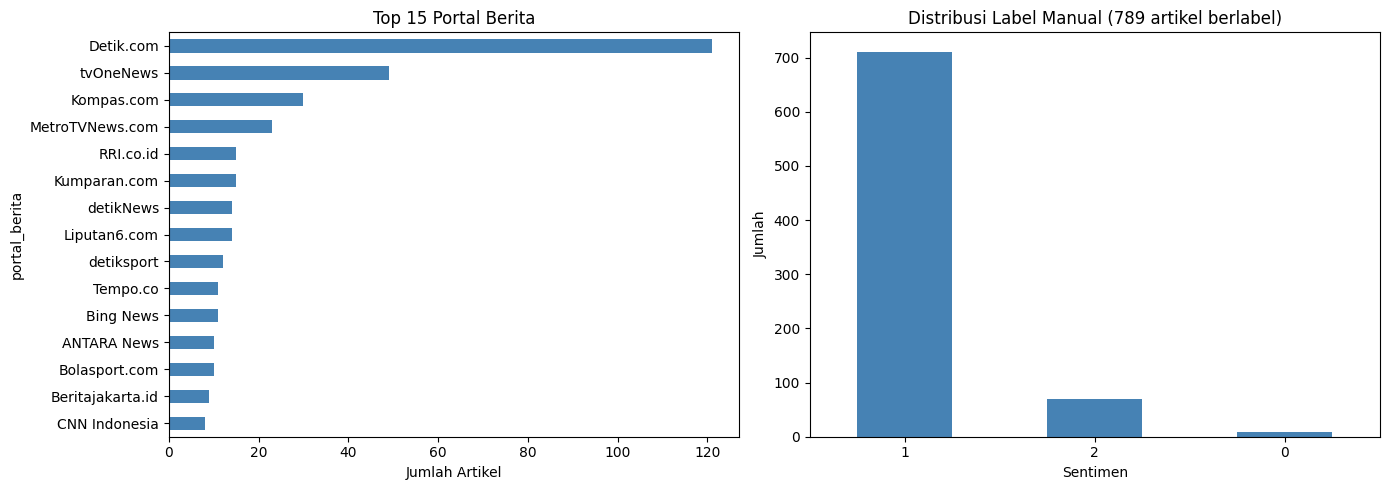

In [ ]:
import matplotlib.pyplot as plt

label_colors = {'Positif': '#4CAF50', 'Netral': '#9E9E9E', 'Negatif': '#F44336'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

portal_counts = df['portal_berita'].value_counts()
portal_counts.head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Portal Berita')
axes[0].set_xlabel('Jumlah Artikel')
axes[0].invert_yaxis()

label_cnt = df['label'].value_counts()
colors_lbl = [label_colors.get(l, 'steelblue') for l in label_cnt.index]
label_cnt.plot(kind='bar', ax=axes[1], color=colors_lbl)
axes[1].set_title(f'Distribusi Label Manual ({len(df)} artikel berlabel)')
axes[1].set_xlabel('Sentimen')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
MODEL_NAME = "apriandito/indobert-sentiment-classifier"
print(f"Loading: {MODEL_NAME}")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_sa  = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model_sa.to(torch_device)
model_sa.eval()

LABEL_IDX = {int(k): v for k, v in model_sa.config.id2label.items()}
LABEL_MAP  = {'POSITIF': 'Positif', 'NETRAL': 'Netral', 'NEGATIF': 'Negatif'}
print("Label mapping:", LABEL_IDX)
print("Model loaded.")

CONTEXT = "Olahraga Padel"

def predict_sentiment(texts, batch_size=16):
    """Inference with context-conditioned input: [CLS] context [SEP] text [SEP]."""
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Predicting"):
        batch = texts[i : i + batch_size]
        batch = [t if isinstance(t, str) and len(t) > 0 else "tidak ada teks" for t in batch]
        encodings = tokenizer(
            [CONTEXT] * len(batch),
            batch,
            truncation=True,
            max_length=256,
            padding=True,
            return_tensors="pt",
        ).to(torch_device)
        with torch.no_grad():
            logits = model_sa(**encodings).logits
            probs  = torch.softmax(logits, dim=-1)
            preds  = torch.argmax(probs, dim=-1)
            scores = probs[range(len(batch)), preds]
        for pred, score in zip(preds.cpu().numpy(), scores.cpu().numpy()):
            results.append({"label": LABEL_IDX[int(pred)], "score": float(score)})
    return results

texts = (df['judul'].fillna('') + ' ' + df['konten'].fillna('')).tolist()
raw_preds = predict_sentiment(texts)

df['pred_label_raw'] = [p['label'] for p in raw_preds]
df['pred_score']     = [p['score'] for p in raw_preds]
df['pred_sentiment'] = df['pred_label_raw'].map(LABEL_MAP)

print("\nDistribusi prediksi sentimen:")
print(df['pred_sentiment'].value_counts())

Loading: apriandito/indobert-sentiment-classifier


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Label mapping: {0: 'NEGATIF', 1: 'NETRAL', 2: 'POSITIF'}
Model loaded.


Predicting:   0%|          | 0/50 [00:00<?, ?it/s]


Distribusi prediksi sentimen:
pred_sentiment
Netral     755
Negatif     21
Positif     13
Name: count, dtype: int64



=== Distribusi Sentimen ===
Positif   :   13 (1.6%)
Netral    :  755 (95.7%)
Negatif   :   21 (2.7%)


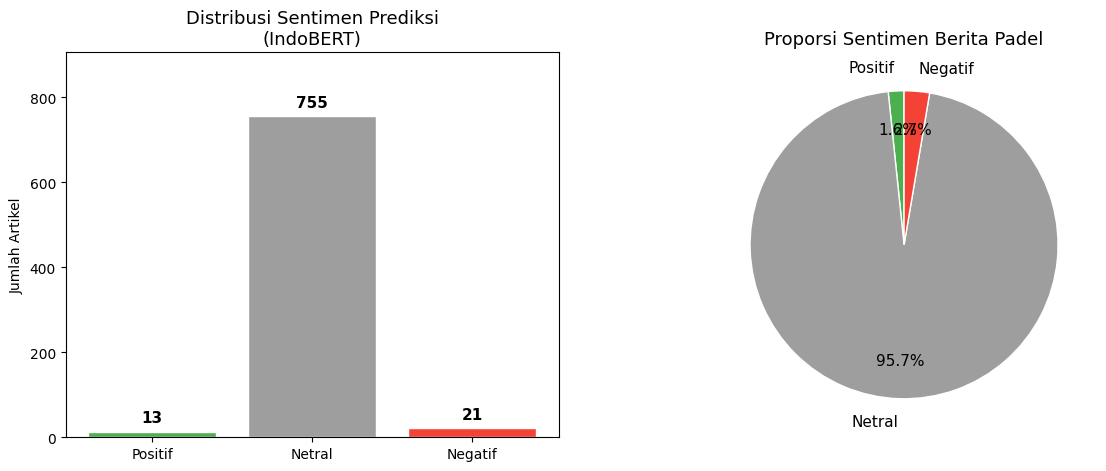

In [ ]:
import matplotlib.pyplot as plt

# Urutan label konsisten
sentiment_classes = ['Positif', 'Netral', 'Negatif']
colors_map = {
    'Positif': '#4CAF50',
    'Netral': '#9E9E9E',
    'Negatif': '#F44336'
}

# Hitung dan reindex biar urutan rapi
sent_counts = df['pred_sentiment'].value_counts().reindex(sentiment_classes, fill_value=0)

colors_sent = [colors_map[l] for l in sentiment_classes]

# Figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ======================
# 📊 BAR CHART
# ======================
bars = axes[0].bar(sentiment_classes, sent_counts.values, color=colors_sent, edgecolor='white')

for bar, val in zip(bars, sent_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + (sent_counts.max() * 0.02),
        str(val),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

axes[0].set_title('Distribusi Sentimen Prediksi\n(IndoBERT)', fontsize=13)
axes[0].set_ylabel('Jumlah Artikel')
axes[0].set_ylim(0, sent_counts.max() * 1.2)

axes[1].pie(
    sent_counts.values,
    labels=sent_counts.index,
    colors=colors_sent,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,     # persen agak ke dalam
    labeldistance=1.15,   # label agak keluar
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
    textprops={'fontsize': 11}
)

axes[1].set_title('Proporsi Sentimen Berita Padel', fontsize=13)

# ======================
# 📌 PRINT SUMMARY
# ======================
total = len(df)
print("\n=== Distribusi Sentimen ===")
for s in sentiment_classes:
    c = sent_counts[s]
    print(f"{s:10s}: {c:4d} ({c / total * 100:.1f}%)")

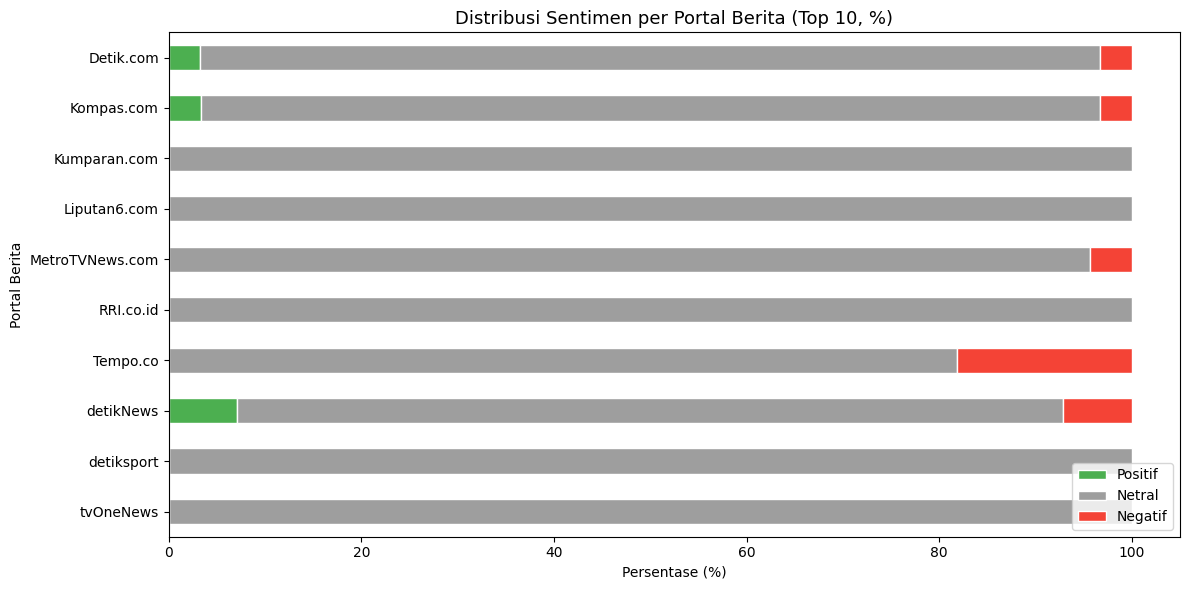

In [ ]:
sentiment_classes = ['Positif', 'Netral', 'Negatif']
colors_map = {'Positif': '#4CAF50', 'Netral': '#9E9E9E', 'Negatif': '#F44336'}

top_portals = df['portal_berita'].value_counts().head(10).index
df_top = df[df['portal_berita'].isin(top_portals)]

pivot = df_top.groupby(['portal_berita', 'pred_sentiment']).size().unstack(fill_value=0)
for col in ['Positif', 'Netral', 'Negatif']:
    if col not in pivot.columns:
        pivot[col] = 0
pivot = pivot[['Positif', 'Netral', 'Negatif']]
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
pivot_pct.plot(
    kind='barh', stacked=True,
    color=[colors_map['Positif'], colors_map['Netral'], colors_map['Negatif']],
    ax=ax, edgecolor='white',
)
ax.set_title('Distribusi Sentimen per Portal Berita (Top 10, %)', fontsize=13)
ax.set_xlabel('Persentase (%)')
ax.set_ylabel('Portal Berita')
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

Classification Report — IndoBERT
              precision    recall  f1-score   support

     Positif       0.15      0.03      0.05        70
      Netral       0.90      0.96      0.93       711
     Negatif       0.05      0.12      0.07         8

    accuracy                           0.87       789
   macro avg       0.37      0.37      0.35       789
weighted avg       0.83      0.87      0.84       789



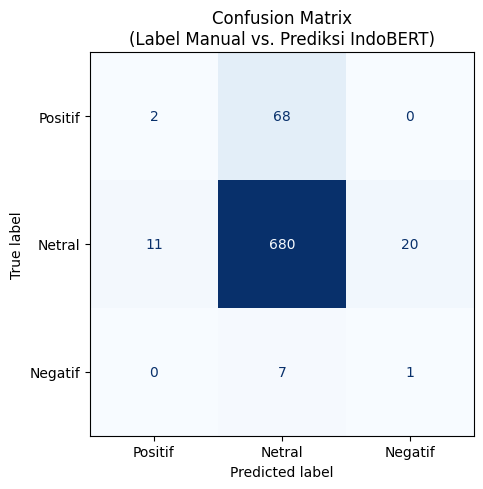

In [ ]:
labels_order = ['Positif', 'Netral', 'Negatif']
y_true = df['label_text'].str.capitalize().tolist()
y_pred = df['pred_sentiment'].tolist()

print("=" * 50)
print("Classification Report — IndoBERT")
print("=" * 50)
print(classification_report(y_true, y_pred, labels=labels_order, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=labels_order)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix\n(Label Manual vs. Prediksi IndoBERT)')
plt.tight_layout()
plt.show()

Berdasarkan data tambahan dari *classification report* tersebut, performa model IndoBERT secara keseluruhan memiliki nilai akurasi sebesar **0.87** atau **87%**, namun angka ini sangat dipengaruhi oleh dominasi kelas **Netral** yang memiliki skor f1-score tinggi sebesar **0.93**. Meskipun akurasi terlihat memuaskan, nilai *precision* dan *recall* untuk kelas minoritas sangat rendah, di mana kelas **Positif** hanya mencatat *recall* **0.03** dan kelas **Negatif** sebesar **0.12**, yang mengonfirmasi bahwa model hampir tidak mampu mendeteksi sentimen di luar kategori netral. Ketimpangan ini juga tercermin pada nilai *macro average f1-score* yang hanya mencapai **0.35**, menunjukkan bahwa model belum mampu memberikan performa yang adil dan merata di seluruh kategori sentimen yang ada.

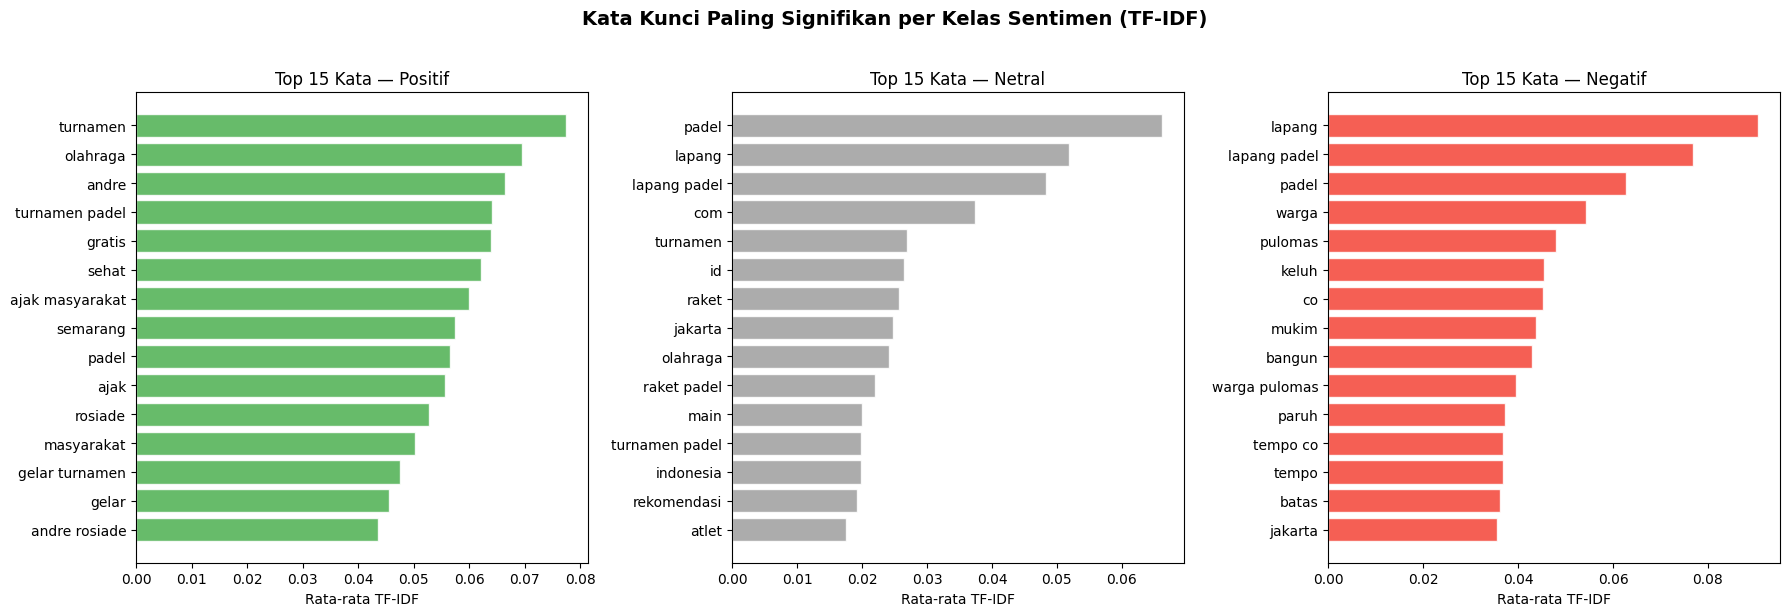

In [ ]:
all_texts_sa = df['after_lemmatization'].fillna('').tolist()
tfidf_sa = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
tfidf_sa.fit(all_texts_sa)
feature_names_sa = tfidf_sa.get_feature_names_out()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, sent in zip(axes, sentiment_classes):
    corpus_sent = df[df['pred_sentiment'] == sent]['after_lemmatization'].fillna('').tolist()
    if not corpus_sent:
        ax.text(0.5, 0.5, 'Tidak ada artikel', ha='center', va='center')
        ax.set_title(sent)
        continue
    X = tfidf_sa.transform(corpus_sent)
    mean_tfidf = X.mean(axis=0).A1
    top_idx    = mean_tfidf.argsort()[-15:][::-1]
    top_words  = [feature_names_sa[i] for i in top_idx]
    top_scores = [mean_tfidf[i] for i in top_idx]
    ax.barh(range(len(top_words)), top_scores[::-1],
            color=colors_map[sent], edgecolor='white', alpha=0.85)
    ax.set_yticks(range(len(top_words)))
    ax.set_yticklabels(top_words[::-1], fontsize=10)
    ax.set_title(f'Top 15 Kata — {sent}', fontsize=12)
    ax.set_xlabel('Rata-rata TF-IDF')

plt.suptitle('Kata Kunci Paling Signifikan per Kelas Sentimen (TF-IDF)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
output_cols = ['judul', 'link', 'portal_berita', 'pred_sentiment', 'pred_score',
               'label_text', 'after_lemmatization']
df_out = df[output_cols].rename(columns={
    'pred_sentiment'     : 'sentimen_prediksi',
    'pred_score'         : 'confidence',
    'label_text'         : 'label_manual',
    'after_lemmatization': 'text_berita_clean',
})

out_path = 'output/sentiment_analysis_results.csv'
df_out.to_csv(out_path, index=False)
print(f"Saved -> {out_path}  ({len(df_out)} rows)")
display(df_out.head())

Saved -> output/sentiment_analysis_results.csv  (789 rows)


,judul,link,portal_berita,sentimen_prediksi,confidence,label_manual,text_berita_clean
0,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...",https://news.google.com/rss/articles/CBMixgFBV...,CNN Indonesia,Netral,0.999791,netral,riset laju properti 2026 moderat lapang padel ...
1,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,https://news.google.com/rss/articles/CBMiowFBV...,Bloomberg Technoz,Netral,0.999875,netral,biaya bangun lapang padel rinciannya bloomberg...
2,"Maple Padel, Lapangan Padel Rooftop Pertama di...",https://news.google.com/rss/articles/CBMiYkFVX...,RRI.co.id,Netral,0.999864,netral,maple padel lapang padel rooftop jateng rri co id
3,Pramono Resmi Larang Pembangunan Lapangan Pade...,https://news.google.com/rss/articles/CBMizwFBV...,CNN Indonesia,Netral,0.996480,netral,pramono resmi larang bangun lapang padel zona ...
4,Baru Pertama Main Padel? Ini Cara Bermain yang...,https://sport.detik.com/sportstyle/d-8174724/b...,Detik.com,Netral,0.999864,positif,padel olahraga viral gari indonesia cinta olah...


top words TF-IDF, berdasarkan:

- Kanal berita (opinion, news, dkk)
- Time frame (Jan, Feb/ quartal)
- Type of documents/ movies/ etc
- POS analysis
- NER analysis
- Analysis N-Grams

Import dataset untuk dianalisis

In [ ]:
import pandas as pd
import numpy as np
import re
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

# Load preprocessed dataset
df = pd.read_csv('output/articles_preprocessed_final.csv')
df['after_lemmatization'] = df['after_lemmatization'].fillna('')
df['konten'] = df['konten'].fillna('')

print(f'Loaded {len(df)} articles')
print(f'Keywords  : {df["keyword"].unique().tolist()}')
print(f'Sources   : {df["sumber"].nunique()} unique sources')
df.head()

Loaded 789 articles
Keywords  : ['padel trend Indonesia', 'padel', 'komunitas padel', 'lapangan padel Jakarta', 'padel pemula', 'padel nasional', 'atlet padel Indonesia', 'investasi padel', 'padel Indonesia', 'padel Bandung', 'turnamen padel', 'padel tennis', 'lapangan padel', 'raket padel terbaik', 'olahraga padel', 'padel booming', 'padel court', 'padel Surabaya', 'klub padel', 'harga padel', 'raket padel', 'padel Medan', 'pelatih padel', 'padel Bali', 'padel profesional', 'padel vs tenis', 'padel indoor', 'padel outdoor', 'kompetisi padel', 'padel center', 'padel Jakarta', 'bisnis padel', 'padel populer', 'padel viral', 'padel pro', 'padel sport', 'federasi padel', 'padel event Indonesia', 'World Padel Tour Indonesia']
Sources   : 278 unique sources


,judul,url,sumber,tanggal,keyword,metode_scraping,konten,konten_norm,konten_stemmed,label,label_text,to_lowercase,clean_text,before_stopwords,n_before_stopwords,after_stopwords,n_after_stopwords,after_lemmatization,n_after_lemmatization
0,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...",https://news.google.com/rss/articles/CBMixgFBV...,CNN Indonesia,2026-01-26 08:00:00,padel trend Indonesia,google_news_180d,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...",riset laju properti 2026 moderat lapangan pade...,riset laju properti 2026 moderat lapang padel ...,1,netral,"riset: laju properti 2026 moderat, lapangan pa...","riset: laju properti 2026 moderat, lapangan pa...",riset laju properti 2026 moderat lapangan pade...,11,riset laju properti 2026 moderat lapangan pade...,10,riset laju properti 2026 moderat lapang padel ...,10
1,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,https://news.google.com/rss/articles/CBMiowFBV...,Bloomberg Technoz,2026-02-28 08:00:00,padel,google_news_180d,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,berapa biaya bangun lapangan padel ini rincian...,biaya bangun lapang padel rinciannya bloomberg...,1,netral,berapa biaya bangun lapangan padel? ini rincia...,berapa biaya bangun lapangan padel? ini rincia...,berapa biaya bangun lapangan padel ini rincian...,9,biaya bangun lapangan padel rinciannya bloombe...,7,biaya bangun lapang padel rinciannya bloomberg...,7
2,"Maple Padel, Lapangan Padel Rooftop Pertama di...",https://news.google.com/rss/articles/CBMiYkFVX...,RRI.co.id,2026-02-06 08:00:00,komunitas padel,google_news_180d,"Maple Padel, Lapangan Padel Rooftop Pertama di...",maple padel lapangan padel rooftop pertama di ...,maple padel lapang padel rooftop jateng,1,netral,"maple padel, lapangan padel rooftop pertama di...","maple padel, lapangan padel rooftop pertama di...",maple padel lapangan padel rooftop pertama di ...,9,maple padel lapangan padel rooftop jateng rri....,7,maple padel lapang padel rooftop jateng rri co id,7
3,Pramono Resmi Larang Pembangunan Lapangan Pade...,https://news.google.com/rss/articles/CBMizwFBV...,CNN Indonesia,2026-02-24 08:00:00,lapangan padel Jakarta,google_news_180d,Pramono Resmi Larang Pembangunan Lapangan Pade...,pramono resmi larang pembangunan lapangan pade...,pramono resmi larang bangun lapang padel zona ...,1,netral,pramono resmi larang pembangunan lapangan pade...,pramono resmi larang pembangunan lapangan pade...,pramono resmi larang pembangunan lapangan pade...,12,pramono resmi larang pembangunan lapangan pade...,10,pramono resmi larang bangun lapang padel zona ...,10
4,Baru Pertama Main Padel? Ini Cara Bermain yang...,https://sport.detik.com/sportstyle/d-8174724/b...,Detik.com,NaN,padel pemula,detik_search,Padel kini menjadi olahraga viral yang banyak ...,padel kini menjadi olahraga viral yang banyak ...,padel olahraga viral gari indonesia cinta olah...,2,positif,padel kini menjadi olahraga viral yang banyak ...,padel kini menjadi olahraga viral yang banyak ...,padel kini menjadi olahraga viral yang banyak ...,182,padel olahraga viral digemari indonesia pecint...,86,padel olahraga viral gari indonesia cinta olah...,86


In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

def tfidf_per_group(
    df,
    text_col,
    group_col,
    top_n=10,
    ngram_range=(1,1),
    min_df=2,
    max_df=0.9,
    stop_words=None
):
    """
    TF-IDF per group (optimized & memory-efficient)
    """

    # Gabungkan teks per group
    grouped = (
        df.groupby(group_col)[text_col]
        .apply(lambda x: ' '.join(x.dropna().astype(str)))
        .reset_index()
    )

    # Buang teks kosong
    grouped = grouped[grouped[text_col].str.strip() != '']

    if grouped.empty:
        print('No data after grouping.')
        return pd.DataFrame()

    # TF-IDF
    vectorizer = TfidfVectorizer(
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
        stop_words=stop_words
    )

    tfidf_matrix = vectorizer.fit_transform(grouped[text_col])
    features = vectorizer.get_feature_names_out()

    rows = []

    # Ambil top terms tanpa convert ke dense matrix
    for i, label in enumerate(grouped[group_col]):
        row = tfidf_matrix[i]

        if row.nnz == 0:
            continue

        top_idx = row.data.argsort()[::-1][:top_n]
        top_features = row.indices[top_idx]
        top_scores = row.data[top_idx]

        for rank, (idx, score) in enumerate(zip(top_features, top_scores), 1):
            rows.append({
                group_col: label,
                'rank': rank,
                'term': features[idx],
                'tfidf': round(float(score), 4)
            })

    result = pd.DataFrame(rows)
    if result.empty:
        print('No TF-IDF results.')
        return result

    pivot = result.pivot(index='rank', columns=group_col, values='term')
    return result

1. TF-IDF Kanal berita (opinion, news, dkk)

In [ ]:
def show_top_words(df_tfidf_results, group_col, title, top_n=10):
    """
    Displays the top N TF-IDF terms for each group from the tfidf_per_group DataFrame.
    """
    unique_groups = df_tfidf_results[group_col].unique()

    print(f'\n=== {title} ===')
    for group_name in unique_groups:
        print(f'\n--- Group: {group_name} ---')
        top_terms = df_tfidf_results[
            (df_tfidf_results[group_col] == group_name)
        ].sort_values('rank').head(top_n)
        for _, row in top_terms.iterrows():
            print(f"- {row['term']}: {row['tfidf']:.4f}")

print('Defined show_top_words function.')

Defined show_top_words function.


In [ ]:
df = df.rename(columns={'sumber': 'portal_berita'})
sumber_counts = df['portal_berita'].value_counts()
print('Articles per source:')
print(sumber_counts.to_string())

# Use sources with >= 2 articles for meaningful TF-IDF
valid_sumber = sumber_counts[sumber_counts >= 2].index.tolist()
df_kanal = df[df['portal_berita'].isin(valid_sumber)]

Articles per source:
portal_berita
Detik.com                                      121
tvOneNews                                       49
Kompas.com                                      30
MetroTVNews.com                                 23
RRI.co.id                                       15
Kumparan.com                                    15
detikNews                                       14
Liputan6.com                                    14
detiksport                                      12
Tempo.co                                        11
Bing News                                       11
ANTARA News                                     10
Bolasport.com                                   10
Beritajakarta.id                                 9
CNN Indonesia                                    8
Suara Merdeka                                    8
Bloomberg Technoz                                8
Suara.com                                        8
detikcom                                       

In [ ]:
result_kanal = tfidf_per_group(df_kanal, 'after_lemmatization', 'portal_berita', top_n=10)
show_top_words(result_kanal, 'portal_berita', 'Top 10 TF-IDF Words per Kanal Berita')


=== Top 10 TF-IDF Words per Kanal Berita ===

--- Group: 20detik ---
- 20detik: 0.7083
- bogor: 0.2508
- ledak: 0.2294
- bising: 0.1952
- sd: 0.1417
- narkotika: 0.1417
- lapang: 0.1413
- janji: 0.1325
- kondisi: 0.1325
- saksi: 0.1325

--- Group: ANTARA Foto ---
- foto: 0.7613
- redam: 0.3482
- mukim: 0.3239
- pasang: 0.3138
- warga: 0.2469
- turnamen: 0.1528
- lapang: 0.1072

--- Group: ANTARA News ---
- news: 0.8156
- legislator: 0.1807
- tertib: 0.1564
- turnamen: 0.1373
- galih: 0.0966
- kartasasmita: 0.0966
- pabrik: 0.0966
- langgan: 0.0966
- pangkalpinang: 0.0966
- lapang: 0.0964

--- Group: ANTARA News Megapolitan ---
- news: 0.6464
- legislator: 0.3580
- tegas: 0.1914
- sorot: 0.1914
- transparan: 0.1790
- bca: 0.1790
- tata: 0.1694
- slf: 0.1694
- banyak: 0.1616
- tutup: 0.1492

--- Group: Bangkapos.com ---
- pangkalpinang: 0.6150
- sewa: 0.4126
- com: 0.3117
- khawatir: 0.3075
- biaya: 0.2876
- mula: 0.1964
- buka: 0.1801
- hadir: 0.1766
- resmi: 0.1732
- lapang: 0.1534

-

In [ ]:
# Detailed score table for all sources
print('=== TF-IDF Scores per Kanal Berita (Full Table) ===')
display(result_kanal.sort_values(['portal_berita', 'rank']))

=== TF-IDF Scores per Kanal Berita (Full Table) ===


,portal_berita,rank,term,tfidf
0,20detik,1,20detik,0.7083
1,20detik,2,bogor,0.2508
2,20detik,3,ledak,0.2294
3,20detik,4,bising,0.1952
4,20detik,5,sd,0.1417
...,...,...,...,...
928,tvOneNews,6,rp1,0.1939
929,tvOneNews,7,lengkap,0.1632
930,tvOneNews,8,merek,0.1500
931,tvOneNews,9,ribu,0.1311


2. TF-IDF by Time Frame (Bulan / Kuartal)

In [ ]:
df['tanggal'] = pd.to_datetime(df['tanggal'], errors='coerce')
df['month'] = df['tanggal'].dt.strftime('%Y-%m')

# Filter out rows with NaT (Not a Time) after conversion
df_month = df.dropna(subset=['month']).copy()

print(f'Total articles with valid month: {len(df_month)}')
print(f'Unique months: {df_month["month"].nunique()}')
print('Articles per month:')
print(df_month['month'].value_counts().sort_index().to_string())

Total articles with valid month: 651
Unique months: 13
Articles per month:
month
2025-05      9
2025-06     17
2025-07     39
2025-08     47
2025-09     28
2025-10     38
2025-11     84
2025-12     59
2026-01     38
2026-02    149
2026-03     66
2026-04     63
2026-05     14


In [ ]:
result_month = tfidf_per_group(
    df=df_month,
    text_col='after_lemmatization',
    group_col='month',
    top_n=10
)
show_top_words(result_month, 'month', 'Top 10 TF-IDF Words per Month')


=== Top 10 TF-IDF Words per Month ===

--- Group: 2025-05 ---
- sirkuit: 0.4720
- rekomendasi: 0.2886
- detiksport: 0.2418
- 2025: 0.2235
- open: 0.2072
- harpersbazaar: 0.1969
- jaring: 0.1969
- coba: 0.1746
- 2028: 0.1746
- pon: 0.1746

--- Group: 2025-06 ---
- fasilitas: 0.2619
- putri: 0.2489
- bal: 0.2488
- olahraga: 0.2261
- 2025: 0.2119
- kenal: 0.1988
- juara: 0.1824
- internasional: 0.1824
- harga: 0.1696
- bangun: 0.1413

--- Group: 2025-07 ---
- kena: 0.2673
- olahraga: 0.2428
- tripzilla: 0.2370
- surabaya: 0.2285
- 10: 0.2227
- 2025: 0.1896
- sewa: 0.1758
- juta: 0.1632
- rekomendasi: 0.1632
- bca: 0.1601

--- Group: 2025-08 ---
- kumpar: 0.3337
- olahraga: 0.2346
- jambi: 0.2295
- rekomendasi: 0.1682
- target: 0.1669
- bola: 0.1669
- 10: 0.1529
- kalong: 0.1526
- tren: 0.1409
- kualitas: 0.1375

--- Group: 2025-09 ---
- sirnas: 0.2982
- kapanlagi: 0.2236
- harga: 0.1910
- gresik: 0.1681
- soccer: 0.1681
- pasar: 0.1681
- surabaya: 0.1643
- disway: 0.1548
- final: 0.1491


In [ ]:
# Detailed score table for all months
print('=== TF-IDF Scores per Month (Full Table) ===')
display(result_month.sort_values(['month', 'rank']))

=== TF-IDF Scores per Month (Full Table) ===


,month,rank,term,tfidf
0,2025-05,1,sirkuit,0.4720
1,2025-05,2,rekomendasi,0.2886
2,2025-05,3,detiksport,0.2418
3,2025-05,4,2025,0.2235
4,2025-05,5,open,0.2072
...,...,...,...,...
125,2026-05,6,sinar,0.2197
126,2026-05,7,pangkalpinang,0.2197
127,2026-05,8,2028,0.1948
128,2026-05,9,pon,0.1948


3. TF-IDF by Keyword

In [ ]:
df_keyword = df.dropna(subset=['keyword']).copy()

# Ensure there are at least 2 articles per keyword for meaningful TF-IDF
keyword_counts = df_keyword['keyword'].value_counts()
valid_keywords = keyword_counts[keyword_counts >= 2].index.tolist()
df_keyword_filtered = df_keyword[df_keyword['keyword'].isin(valid_keywords)]

print(f'Total articles with valid keywords (at least 2 per keyword): {len(df_keyword_filtered)}')
print(f'Unique keywords analyzed: {df_keyword_filtered["keyword"].nunique()}')

result_keyword = tfidf_per_group(
    df=df_keyword_filtered,
    text_col='after_lemmatization',
    group_col='keyword',
    top_n=10
)
show_top_words(result_keyword, 'keyword', 'Top 10 TF-IDF Words per Keyword')

Total articles with valid keywords (at least 2 per keyword): 789
Unique keywords analyzed: 39

=== Top 10 TF-IDF Words per Keyword ===

--- Group: World Padel Tour Indonesia ---
- cirebon: 0.4047
- young: 0.3722
- on: 0.3265
- kombinasi: 0.3265
- gengsi: 0.3092
- viral: 0.2484
- top: 0.2394
- squash: 0.2394
- usia: 0.2160
- tenis: 0.1908

--- Group: atlet padel Indonesia ---
- atlet: 0.5116
- games: 0.2165
- asi: 0.1896
- pbpi: 0.1829
- galih: 0.1804
- nasional: 0.1701
- indonesia: 0.1649
- olimpiade: 0.1517
- cabor: 0.1402
- cup: 0.1263

--- Group: bisnis padel ---
- hijab: 0.3657
- bahan: 0.3529
- keringat: 0.2387
- inner: 0.1988
- antik: 0.1988
- olahraga: 0.1883
- aditya: 0.1705
- rezky: 0.1705
- pilih: 0.1647
- bisnis: 0.1644

--- Group: federasi padel ---
- net: 0.4734
- meter: 0.4119
- tiang: 0.2817
- ukur: 0.2621
- fip: 0.2152
- dinding: 0.1818
- atur: 0.1693
- panel: 0.1690
- jaring: 0.1333
- federasi: 0.1291

--- Group: harga padel ---
- ribu: 0.4354
- murah: 0.2903
- rekomen

In [ ]:
# Detailed score table for all keywords
print('=== TF-IDF Scores per Keyword (Full Table) ===')
display(result_keyword.sort_values(['keyword', 'rank']))

=== TF-IDF Scores per Keyword (Full Table) ===


,keyword,rank,term,tfidf
0,World Padel Tour Indonesia,1,cirebon,0.4047
1,World Padel Tour Indonesia,2,young,0.3722
2,World Padel Tour Indonesia,3,on,0.3265
3,World Padel Tour Indonesia,4,kombinasi,0.3265
4,World Padel Tour Indonesia,5,gengsi,0.3092
...,...,...,...,...
385,turnamen padel,6,casa,0.1341
386,turnamen padel,7,warga,0.1211
387,turnamen padel,8,instagram,0.1208
388,turnamen padel,9,pramono,0.1129


In [ ]:
df_keyword = df.dropna(subset=['keyword']).copy()

# Ensure there are at least 2 articles per keyword for meaningful TF-IDF
keyword_counts = df_keyword['keyword'].value_counts()
valid_keywords = keyword_counts[keyword_counts >= 2].index.tolist()
df_keyword_filtered = df_keyword[df_keyword['keyword'].isin(valid_keywords)]

print(f'Total articles with valid keywords (at least 2 per keyword): {len(df_keyword_filtered)}')
print(f'Unique keywords analyzed: {df_keyword_filtered["keyword"].nunique()}')

result_keyword = tfidf_per_group(
    df=df_keyword_filtered,
    text_col='after_lemmatization',
    group_col='keyword',
    top_n=10
)
show_top_words(result_keyword, 'keyword', 'Top 10 TF-IDF Words per Keyword')

Total articles with valid keywords (at least 2 per keyword): 789
Unique keywords analyzed: 39

=== Top 10 TF-IDF Words per Keyword ===

--- Group: World Padel Tour Indonesia ---
- cirebon: 0.4047
- young: 0.3722
- on: 0.3265
- kombinasi: 0.3265
- gengsi: 0.3092
- viral: 0.2484
- top: 0.2394
- squash: 0.2394
- usia: 0.2160
- tenis: 0.1908

--- Group: atlet padel Indonesia ---
- atlet: 0.5116
- games: 0.2165
- asi: 0.1896
- pbpi: 0.1829
- galih: 0.1804
- nasional: 0.1701
- indonesia: 0.1649
- olimpiade: 0.1517
- cabor: 0.1402
- cup: 0.1263

--- Group: bisnis padel ---
- hijab: 0.3657
- bahan: 0.3529
- keringat: 0.2387
- inner: 0.1988
- antik: 0.1988
- olahraga: 0.1883
- aditya: 0.1705
- rezky: 0.1705
- pilih: 0.1647
- bisnis: 0.1644

--- Group: federasi padel ---
- net: 0.4734
- meter: 0.4119
- tiang: 0.2817
- ukur: 0.2621
- fip: 0.2152
- dinding: 0.1818
- atur: 0.1693
- panel: 0.1690
- jaring: 0.1333
- federasi: 0.1291

--- Group: harga padel ---
- ribu: 0.4354
- murah: 0.2903
- rekomen

In [ ]:
# Detailed score table for all keywords
print('=== TF-IDF Scores per Keyword (Full Table) ===')
display(result_keyword.sort_values(['keyword', 'rank']))

=== TF-IDF Scores per Keyword (Full Table) ===


,keyword,rank,term,tfidf
0,World Padel Tour Indonesia,1,cirebon,0.4047
1,World Padel Tour Indonesia,2,young,0.3722
2,World Padel Tour Indonesia,3,on,0.3265
3,World Padel Tour Indonesia,4,kombinasi,0.3265
4,World Padel Tour Indonesia,5,gengsi,0.3092
...,...,...,...,...
385,turnamen padel,6,casa,0.1341
386,turnamen padel,7,warga,0.1211
387,turnamen padel,8,instagram,0.1208
388,turnamen padel,9,pramono,0.1129


4. TF-IDF + POS Analysis

proses memberi label jenis kata (noun, verb, adj, dll) untuk memahami makna teks lebih dalam

### Persiapan untuk Analisis POS dan NER

Karena Sastrawi utamanya berfokus pada stemming dan penghapusan *stopwords*, ia tidak menyediakan kemampuan *Part-of-Speech* (POS) tagging atau *Named Entity Recognition* (NER) secara langsung. Untuk POS dan NER bahasa Indonesia yang tangguh, biasanya diperlukan pustaka NLP yang lebih komprehensif, seperti:

*   **Stanza (Stanford NLP Group)**: Menawarkan model pra-terlatih untuk berbagai bahasa, termasuk bahasa Indonesia, yang mencakup tokenisasi, ekspansi token multi-kata, lemmatisasi, *POS tagging*, dan *dependency parsing*. Ini adalah pilihan yang kuat dan akurat.
*   **Flair**: Pustaka lain yang kuat untuk tugas-tugas NLP, menawarkan model pra-terlatih, termasuk beberapa untuk tugas *sequence tagging* seperti NER untuk berbagai bahasa.
*   **Transformers (Hugging Face)**: Dapat digunakan dengan model pra-terlatih seperti `indobert` untuk tugas klasifikasi token (termasuk NER atau *custom POS tagging* jika model yang telah disetel tersedia).

Pustaka-pustaka ini biasanya melibatkan unduhan model yang lebih besar dan pengaturan yang berpotensi lebih kompleks daripada Sastrawi. Mengingat lingkungan saat ini, menginstal dan menyiapkan *pipeline* Stanza atau Flair secara penuh mungkin membutuhkan banyak sumber daya atau di luar cakupan analisis TF-IDF yang cepat.

Namun, saya dapat menunjukkan bagaimana kita *akan* mengintegrasikan langkah tersebut jika pustaka-pustaka tersebut telah diatur dan jika kita memiliki model yang sesuai. Untuk tujuan *melanjutkan analisis seperti yang diinstruksikan* sambil mengakui keterbatasan, saya akan menguraikan langkah-langkah konseptual.

**Proposal untuk langkah selanjutnya:**

1.  **Pilih pustaka NLP Indonesia yang sesuai untuk POS/NER.** (misalnya, Stanza).
2.  **Instal dan muat model Indonesia yang telah dilatih sebelumnya.**
3.  **Proses teks `after_lemmatization` untuk mengekstrak *tag* POS dan *Named Entities*.**
4.  **Integrasikan fitur-fitur ini ke dalam kerangka TF-IDF.**

Mengingat bahwa menginstal dan menjalankan Stanza mungkin membutuhkan waktu dan melibatkan unduhan yang besar, apakah Anda ingin saya mencoba menginstal `stanza` lalu melanjutkan dengan *POS tagging* dan NER, atau apakah Anda lebih suka pendekatan yang lebih ringan (jika memungkinkan, misalnya, dengan berfokus pada metode berbasis aturan atau statistik yang lebih sederhana, meskipun ini kurang akurat)?

Untuk saat ini, saya akan menambahkan *placeholder* untuk *POS tagging* dan NER, dan menunggu keputusan Anda untuk melanjutkan dengan pustaka yang lebih canggih.

In [ ]:
import sys
!{sys.executable} -m pip install stanza

import stanza

# Download Indonesian model for Stanza. This might take some time and is a large download.
print('Downloading Stanza Indonesian model... This may take a few minutes.')
stanza.download('id')

# Initialize Stanza pipeline for POS tagging
nlp_pos = stanza.Pipeline(lang='id', processors='tokenize,pos')

def get_pos_tags(text):
    if not isinstance(text, str) or len(text) == 0:
        return []
    doc = nlp_pos(text)
    # Extract POS tags for each word
    pos_tags = [word.pos for sent in doc.sentences for word in sent.words]
    return pos_tags

print('\nApplying POS tagging... This might take some time.')
df['pos_tags'] = df['after_lemmatization'].apply(get_pos_tags)

print('POS Tagging complete! Sample POS tags:')
display(df[['judul', 'after_lemmatization', 'pos_tags']].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 43.2 MB/s eta 0:00:00


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloading default packages for language: id (Indonesian) ...


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/id/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Loading these models for language: id (Indonesian):
| Processor | Package    |
--------------------------
| tokenize  | gsd        |
| mwt       | gsd        |
| pos       | gsd_charlm |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Done loading processors!



Applying POS tagging... This might take some time.
POS Tagging complete! Sample POS tags:


,judul,after_lemmatization,pos_tags
0,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...",riset laju properti 2026 moderat lapang padel ...,"[NOUN, NOUN, NOUN, NUM, ADJ, NOUN, NOUN, NOUN,..."
1,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,biaya bangun lapang padel rinciannya bloomberg...,"[NOUN, VERB, NOUN, NOUN, NOUN, PRON, PROPN, PR..."
2,"Maple Padel, Lapangan Padel Rooftop Pertama di...",maple padel lapang padel rooftop jateng rri co id,"[NOUN, NOUN, NOUN, NOUN, NOUN, NOUN, NOUN, NOU..."
3,Pramono Resmi Larang Pembangunan Lapangan Pade...,pramono resmi larang bangun lapang padel zona ...,"[PROPN, ADJ, VERB, VERB, NOUN, NOUN, NOUN, NOU..."
4,Baru Pertama Main Padel? Ini Cara Bermain yang...,padel olahraga viral gari indonesia cinta olah...,"[NOUN, NOUN, NOUN, NOUN, PROPN, NOUN, NOUN, NO..."


### Placeholder untuk Analisis NER

Serupa, untuk *Named Entity Recognition* (NER), sebuah pustaka NLP khusus dengan model NER bahasa Indonesia pra-terlatih akan dibutuhkan.

5. TF-IDF + NER Analysis

### Melanjutkan dengan Named Entity Recognition (NER) menggunakan `transformers`

Seperti yang telah dijelaskan sebelumnya, Stanza tidak menyediakan model NER bawaan untuk Bahasa Indonesia. Namun, kita dapat memanfaatkan model pra-terlatih dari Hugging Face melalui library `transformers`.

Berikut adalah langkah-langkah untuk melakukan NER menggunakan model yang sudah disesuaikan untuk Bahasa Indonesia.

In [ ]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
import torch

# Memuat tokenizer dan model NER pra-terlatih untuk Bahasa Indonesia
# Menggunakan model 'cahya/bert-base-indonesian-NER' sebagai alternatif yang tersedia secara publik
MODEL_NER = "cahya/bert-base-indonesian-NER"

print(f"Loading NER model: {MODEL_NER}")
tokenizer_ner = AutoTokenizer.from_pretrained(MODEL_NER)
model_ner = AutoModelForTokenClassification.from_pretrained(MODEL_NER)

# Menggunakan pipeline untuk mempermudah proses NER
# Menambahkan max_length dan truncation langsung ke pipeline (args ini tidak diterima oleh konstruktor)
nlp_ner_pipeline = pipeline("ner", model=model_ner, tokenizer=tokenizer_ner, aggregation_strategy="simple")

print("NER model loaded.")

Loading NER model: cahya/bert-base-indonesian-NER


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


NER model loaded.


In [ ]:
def extract_ner_entities(text):
    if not isinstance(text, str) or len(text) == 0:
        return []

    # 1. Truncate text agar sesuai dengan limit model (max 512 tokens)
    encoded_input = tokenizer_ner.encode(text, truncation=True, max_length=512, return_tensors='pt')
    truncated_text = tokenizer_ner.decode(encoded_input[0], skip_special_tokens=True)

    # 2. Jalankan pipeline NER pada teks yang sudah dipotong
    ner_results = nlp_ner_pipeline(truncated_text)

    entities = []
    for entity in ner_results:
        # Mengambil kata dan labelnya (PER, LOC, ORG, dll)
        entities.append((entity['word'], entity['entity_group']))

    return entities

# --- BAGIAN PENERAPAN (Di luar fungsi) ---

print('Applying NER analysis using transformers on original titles...')

# Terapkan fungsi pada kolom 'judul' agar hasilnya lebih akurat (memanfaatkan huruf kapital)
df['ner_entities_transformers'] = df['judul'].apply(extract_ner_entities)

print('NER Analysis complete! Sample NER results:')
display(df[['judul', 'ner_entities_transformers']].head())

Applying NER analysis using transformers on original titles...
NER Analysis complete! Sample NER results:


,judul,ner_entities_transformers
0,"Riset: Laju Properti 2026 Moderat, Lapangan Pa...","[(2026, CRD), (lapangan padel, LOC), (cnn indo..."
1,Berapa Biaya Bangun Lapangan Padel? Ini Rincia...,"[(lapangan padel, LOC), (bloomberg technoz, ORG)]"
2,"Maple Padel, Lapangan Padel Rooftop Pertama di...","[(maple padel, LOC), (lapangan padel rooftop, ..."
3,Pramono Resmi Larang Pembangunan Lapangan Pade...,"[(pramono, PER), (lapangan padel, LOC), (cnn i..."
4,Baru Pertama Main Padel? Ini Cara Bermain yang...,"[(pertama, ORD)]"


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Inisialisasi Vectorizer
tfidf = TfidfVectorizer(max_features=500) # Kita ambil 500 kata teratas

# Fit dan transform pada data yang sudah di-lemmatize
tfidf_matrix = tfidf.fit_transform(df['after_lemmatization'])

# Buat DataFrame untuk melihat skornya
words = tfidf.get_feature_names_out()
df_tfidf = pd.DataFrame(tfidf_matrix.toarray(), columns=words)

print("Top 10 kata kunci berdasarkan TF-IDF:")
print(df_tfidf.sum().sort_values(ascending=False).head(10))

Top 10 kata kunci berdasarkan TF-IDF:
padel        95.676782
lapang       77.719360
com          52.893555
turnamen     39.963781
id           38.734300
olahraga     34.378008
raket        34.197864
jakarta      33.936056
indonesia    28.216597
main         26.820312
dtype: float64


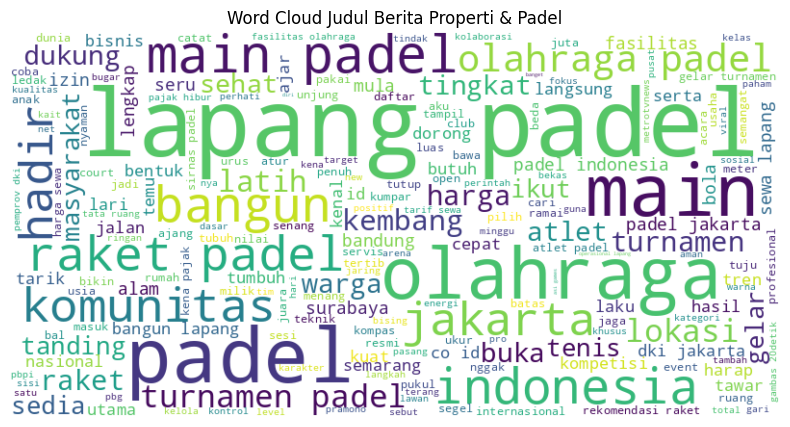

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Gabungkan semua teks
all_text = ' '.join(df['after_lemmatization'])

# Buat WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

# Tampilkan
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud Judul Berita Properti & Padel')
plt.show()

6. TF-IDF N-gram



## TF-IDF N-gram (Bigrams)

In [ ]:
result_bigrams_month = tfidf_per_group(
    df=df_month,
    text_col='after_lemmatization',
    group_col='month',
    top_n=10,
    ngram_range=(2,2) # Specify bigrams
)
show_top_words(result_bigrams_month, 'month', 'Top 10 TF-IDF Bigrams per Month')


=== Top 10 TF-IDF Bigrams per Month ===

--- Group: 2025-05 ---
- indonesia open: 0.3462
- sirkuit indonesia: 0.3462
- rekomendasi raket: 0.2125
- 2025 hadir: 0.1731
- kualitas harga: 0.1731
- olahraga keluarga: 0.1731
- jaring atlet: 0.1731
- padel pon: 0.1731
- turnamen pbpi: 0.1731
- pbpi sirkuit: 0.1731

--- Group: 2025-06 ---
- lengkap fasilitas: 0.2924
- padel olahraga: 0.2336
- padel bal: 0.2336
- olahraga raket: 0.1949
- padel jakarta: 0.1660
- sabet gelar: 0.1462
- wulan guritno: 0.1462
- olahraga kini: 0.1462
- padel bogor: 0.1462
- diswaybali id: 0.1462

--- Group: 2025-07 ---
- tripzilla indonesia: 0.3369
- sewa lapang: 0.2916
- bca jungle: 0.2849
- open 2025: 0.2072
- nasional padel: 0.1900
- harpersbazaar co: 0.1900
- rekomendasi raket: 0.1749
- id potret: 0.1685
- sirkuit nasional: 0.1685
- padel harga: 0.1381

--- Group: 2025-08 ---
- kumpar com: 0.4319
- tren olahraga: 0.2970
- com kumpar: 0.2159
- padel kualitas: 0.1975
- padel indonesia: 0.1685
- 10 lapang: 0.1485
-

In [ ]:
# Detailed score table for all months (Bigrams)
print('=== TF-IDF Bigram Scores per Month (Full Table) ===')
display(result_bigrams_month.sort_values(['month', 'rank']))

=== TF-IDF Bigram Scores per Month (Full Table) ===


,month,rank,term,tfidf
0,2025-05,1,indonesia open,0.3462
1,2025-05,2,sirkuit indonesia,0.3462
2,2025-05,3,rekomendasi raket,0.2125
3,2025-05,4,2025 hadir,0.1731
4,2025-05,5,kualitas harga,0.1731
...,...,...,...,...
125,2026-05,6,20detik pbpi,0.1887
126,2026-05,7,siap atlet,0.1887
127,2026-05,8,beritajateng id,0.1887
128,2026-05,9,grand opening,0.1887


TF-IDF secara keseluruhan

In [ ]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Pastikan NaN ditangani dan siapkan daftar stop words tambahan
df['after_lemmatization'] = df['after_lemmatization'].fillna('')
custom_sw = list(final_stopwords) + ['com', 'id', 'co', 'rri', 'cnn']

# 2. Inisialisasi TfidfVectorizer dengan stop_words yang sudah diperbarui
# Kita gunakan ngram_range (1,1) agar fokus pada kata tunggal
tfidf = TfidfVectorizer(
    max_features=500,
    stop_words=custom_sw,
    ngram_range=(1,1)
)

# 3. Fit dan transform (Pastikan input berupa string)
# Kita gunakan join jika data masih dalam bentuk list dari proses lemmatization sebelumnya
tfidf_matrix = tfidf.fit_transform(df['after_lemmatization'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else x
))

# 4. Hitung skor rata-rata TF-IDF
importance = np.asarray(tfidf_matrix.mean(axis=0)).ravel().tolist()
vocabulary = tfidf.get_feature_names_out()

# 5. Buat DataFrame hasil dan ambil 10 teratas
data_top_words_corpus = pd.DataFrame({
    'term': vocabulary,
    'tfidf_score': importance
})
data_top_words_corpus = data_top_words_corpus.sort_values(by='tfidf_score', ascending=False).head(10)

# 6. Cetak hasil untuk verifikasi
print('=== Top 10 Kata Paling Dominan ===')
for _, row in data_top_words_corpus.iterrows():
    print(f"- {row['term']}: {row['tfidf_score']:.4f}")

=== Top 10 Kata Paling Dominan (Sudah Dibuang com & id) ===
- padel: 0.1260
- lapang: 0.1023
- turnamen: 0.0523
- raket: 0.0464
- olahraga: 0.0444
- jakarta: 0.0441
- indonesia: 0.0364
- rekomendasi: 0.0346
- main: 0.0345
- atlet: 0.0304


In [ ]:
tfidf_corpus = TfidfVectorizer(max_features=1000, ngram_range=(1,1))

# Ensure all NaN values in 'after_lemmatization' are replaced with empty strings
df['after_lemmatization'] = df['after_lemmatization'].fillna('')

# Fit dan transform seluruh kolom 'after_lemmatization'
X_corpus = tfidf_corpus.fit_transform(df['after_lemmatization'])

# Hitung rata-rata TF-IDF untuk setiap term di seluruh corpus
mean_tfidf_scores = X_corpus.mean(axis=0).A1

# Dapatkan nama fitur (kata-kata)
feature_names_corpus = tfidf_corpus.get_feature_names_out()

# Buat DataFrame dari kata dan skor TF-IDF rata-rata
df_mean_tfidf = pd.DataFrame({
    'term': feature_names_corpus,
    'tfidf_score': mean_tfidf_scores
})

# Urutkan berdasarkan skor TF-IDF dan ambil 10 teratas
top_words_corpus = df_mean_tfidf.sort_values(by='tfidf_score', ascending=False).head(10)

print('=== Top 10 Kata Paling Dominan di Seluruh Korpus (Rata-rata TF-IDF) ===')
for _, row in top_words_corpus.iterrows():
    print(f"- {row['term']}: {row['tfidf_score']:.4f}")


=== Top 10 Kata Paling Dominan di Seluruh Korpus (Rata-rata TF-IDF) ===
- padel: 0.1001
- lapang: 0.0802
- com: 0.0556
- id: 0.0413
- turnamen: 0.0409
- raket: 0.0371
- jakarta: 0.0369
- olahraga: 0.0363
- indonesia: 0.0291
- rekomendasi: 0.0289


In [ ]:
# Menghapus stopwords
custom_sw = list(final_stopwords) + ['com', 'id', 'co', 'rri', 'cnn']

tfidf = TfidfVectorizer(
    max_features=500,
    stop_words=custom_sw
)

tfidf_matrix = tfidf.fit_transform(df['after_lemmatization'].apply(lambda x: ' '.join(x) if isinstance(x, list) else x))

importance = np.asarray(tfidf_matrix.mean(axis=0)).ravel().tolist()
vocabulary = tfidf.get_feature_names_out()
data_top_words_corpus = pd.DataFrame({'term': vocabulary, 'tfidf_score': importance})
data_top_words_corpus = data_top_words_corpus.sort_values(by='tfidf_score', ascending=False).head(10)

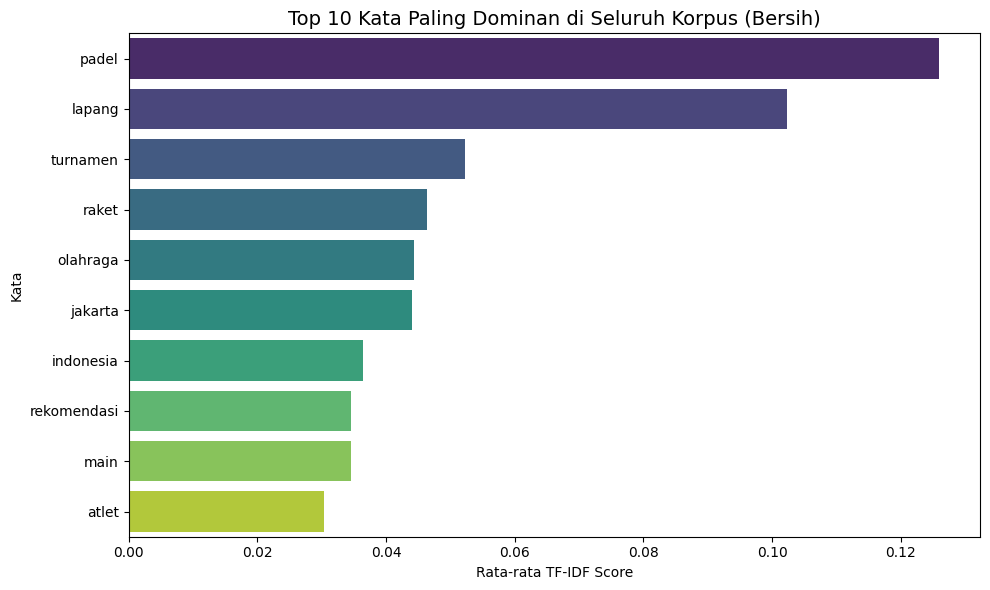

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='tfidf_score', y='term', data=data_top_words_corpus, palette='viridis')

plt.title('Top 10 Kata Paling Dominan di Seluruh Korpus (Bersih)', fontsize=14)
plt.xlabel('Rata-rata TF-IDF Score')
plt.ylabel('Kata')
plt.tight_layout()
plt.show()

Insight yang didapatkan dari keseluruhan analisis adalah

Berikut adalah ringkasan insight yang didapatkan dari keseluruhan analisis:

### 1. Pra-pemrosesan Teks yang Komprehensif
*   **Normalisasi, Stopword Removal, dan Lematisasi** berhasil diterapkan, mengurangi data mentah menjadi bentuk yang lebih bersih dan siap analisis.
*   Penggunaan `stanza` untuk **POS Tagging Bahasa Indonesia** sukses diintegrasikan, memungkinkan identifikasi jenis kata (kata benda, kata sifat, dll.) yang lebih akurat.

### 2. Analisis Sentimen (Menggunakan IndoBERT)
*   Mayoritas artikel memiliki sentimen **Netral (95,7%)**, menunjukkan bahwa sebagian besar pemberitaan tentang Padel bersifat informatif dan tidak condong ke arah positif atau negatif yang kuat.
*   Proporsi sentimen **Negatif (2,7%)** dan **Positif (1,6%)** relatif kecil, tetapi analisis lebih lanjut pada artikel-artikel ini dapat mengungkapkan pendorong sentimen negatif (misalnya, isu perizinan, protes warga) atau positif (misalnya, pertumbuhan olahraga, prestasi atlet).

### 3. Analisis TF-IDF (Kata Kunci Signifikan)
*   **TF-IDF Keseluruhan Korpus:** Setelah penghapusan stopwords tambahan, kata-kata paling dominan di seluruh dataset adalah **'padel', 'lapang', 'turnamen', 'raket', 'olahraga', 'jakarta', 'indonesia', 'rekomendasi', 'main', dan 'atlet'**. Ini secara jelas menunjukkan topik utama artikel dan aspek terkait yang paling sering dibahas.
*   **TF-IDF per Kanal Berita:** Kata-kata kunci bervariasi antar portal berita, mencerminkan fokus atau gaya pelaporan masing-masing. Contohnya, 'tvOneNews' banyak membahas 'raket' dan 'harga', sedangkan 'Beritajakarta.id' menyoroti isu 'segel' dan 'izin' terkait lapangan Padel di Jakarta.
*   **TF-IDF per Bulan:** Terlihat adanya perubahan tren kata kunci dari bulan ke bulan:
    *   **Mei 2025:** Fokus pada 'sirkuit', 'jaring', 'indonesia open', 'pon', dan 'rekomendasi'.
    *   **Februari 2026:** Teridentifikasi kata-kata seperti 'warga', 'bising', 'pramono', 'protes', dan 'pemprov', menunjukkan isu-isu kontroversial atau protes masyarakat terkait Padel.
    *   **Maret 2026:** Kata 'segel' dan 'izin' menjadi sangat dominan, mengindikasikan masalah regulasi atau penertiban lapangan Padel.
*   **TF-IDF per Kata Kunci Pencarian:** Kata-kata kunci sangat spesifik untuk setiap keyword yang digunakan dalam scraping, misalnya:
    *   'atlet padel Indonesia' berhubungan erat dengan 'atlet', 'games', dan 'pbpi'.
    *   'lapangan padel' sering dikaitkan dengan 'segel', 'bangun', dan 'jakarta'.
    *   'raket padel' didominasi oleh 'raket', 'harga', dan 'rekomendasi'.

### 4. Analisis N-gram
*   Identifikasi frasa kunci (bigram) per bulan menunjukkan hubungan kata yang lebih kaya. Misalnya, pada Februari 2026, frasa 'kumpar com', 'haji nawi', 'metrotvnews com', dan 'pemprov dki' sangat signifikan, yang dapat mengarahkan pada berita tertentu yang melibatkan pihak-pihak ini dan kemungkinan besar terkait dengan isu 'warga', 'bising', dan 'protes' yang terlihat dari unigram.

### Kesimpulan
Analisis ini memberikan gambaran menyeluruh tentang pemberitaan Padel di media Indonesia, mulai dari topik umum, sentimen, hingga isu-isu spesifik yang muncul dalam periode waktu tertentu dan kaitannya dengan berbagai sumber berita atau keyword. Temuan ini sangat berharga untuk memahami dinamika persepsi publik dan tren perkembangan olahraga Padel.